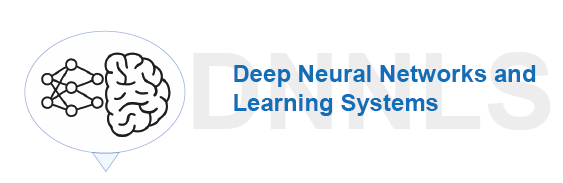

# Final assessment For Arinze Uwazurike - Main Notebook
---

**Introduction:**

In this notebook you will find a baseline, functional architecture for your assessment task.

In [1]:
# @title Importing the necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np
import os
from nltk.translate.bleu_score import sentence_bleu
import json
import pandas as pd
from torchinfo import summary
from transformers import RobertaModel



from datasets.fingerprint import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

import torchvision.transforms.functional as FT

from transformers import BertTokenizer
import gc

import textwrap


C:\Users\dell 5590 i7\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Chapter 1: The data preparation**


---



First we need to activate our google drive so that we can save out data permanently.

## 1.1 Loading and saving data

In [2]:
# @title Local checkpoint saving
"""
This version saves checkpoints locally
"""
#Modified
import os
import torch

def save_checkpoint(model, optimizer, epoch, loss, filename="autoencoder_checkpoint.pth"):
    """
    Saves the checkpoint to a local folder.
    """
    # Local folder
    local_folder = './checkpoints'

    # Ensure the directory exists
    os.makedirs(local_folder, exist_ok=True)

    # Full file path
    full_path = os.path.join(local_folder, filename)

    # Create checkpoint dictionary
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }

    # Save checkpoint
    torch.save(checkpoint, full_path)
    print(f"Checkpoint saved locally: {full_path} at epoch {epoch}")


def load_checkpoint(model, optimizer=None, filename="autoencoder_checkpoint.pth"):
    """
    Loads a checkpoint from the local folder.
    """
    local_folder = './checkpoints'
    full_path = os.path.join(local_folder, filename)

    # Check if file exists
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Checkpoint file not found: {full_path}")

    # Load checkpoint
    checkpoint = torch.load(full_path, map_location=torch.device('cpu'))

    # Restore model state
    model.load_state_dict(checkpoint['model_state_dict'])

    # Restore optimizer state (if provided)
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # Extract metadata
    epoch = checkpoint.get('epoch', 0)
    loss = checkpoint.get('loss', None)

    print(f"Checkpoint loaded from: {full_path} (epoch {epoch})")

    return model, optimizer, epoch, loss

We need to define a couple of functions to make our life easier. Feel free to tweak those functions:

In [3]:
from src.final_training import (N_EPOCHS, emb_dim, latent_dim, num_layers, lr, max_seq_len, batch_size, dropout)
N_EPOCHS = N_EPOCHS
emb_dim = emb_dim
latent_dim = latent_dim
num_layers = num_layers
lr = lr
max_seq_len = max_seq_len
batch_size = batch_size
dropout = dropout

In [4]:
# @title Functions to show images and process data
"""
This cell provides essential data processing and visualization tools.
1. `parse_gdi_text`: Parses the raw "GDI" (Graph-Text-Interleaved) format from the dataset into a structured dictionary containing objects, actions, and locations.
2. `show_image`: A helper using matplotlib to display pytorch tensors as images, handling optional de-normalization.
"""

# This function just extracts the tags from the text, don't get distracted by it.
# I changed this function a bit to fix some bugs
def parse_gdi_text(text):
    """Parse GDI formatted text into structured data"""
    soup = BeautifulSoup(text, 'html.parser')
    images = []

    for gdi in soup.find_all('gdi'):
        # Debug: print what BeautifulSoup sees

        # Method 1: Try to get image attribute directly
        image_id = None
        if gdi.attrs:
            # Check for attributes like 'image1', 'image2', etc.
            for attr_name, attr_value in gdi.attrs.items():
                if 'image' in attr_name.lower():
                    image_id = attr_name.replace('image', '')
                    break

        # Method 2: Extract from the tag string using regex
        if not image_id:
            tag_str = str(gdi)
            match = re.search(r'<gdi\s+image(\d+)', tag_str)
            if match:
                image_id = match.group(1)

        # Method 3: Fallback - use sequential numbering
        if not image_id:
            image_id = str(len(images) + 1)

        content = gdi.get_text().strip()

        # Extract tagged elements using BeautifulSoup directly
        objects = [obj.get_text().strip() for obj in gdi.find_all('gdo')]
        actions = [act.get_text().strip() for act in gdi.find_all('gda')]
        locations = [loc.get_text().strip() for loc in gdi.find_all('gdl')]

        images.append({
            'image_id': image_id,
            'description': content,
            'objects': objects,
            'actions': actions,
            'locations': locations,
            'raw_text': str(gdi)
        })

    return images

# This is an utility function to show images.
# Why do we need to do all this?
def show_image(ax, image, de_normalize = False, img_mean = None, img_std = None):
  """
  De-normalize the image (if necessary) and show image
  """
  if de_normalize:
    new_mean = -img_mean/img_std
    new_std = 1/img_std

    image = transforms.Normalize(
        mean=new_mean,
        std=new_std
    )(image)
  ax.imshow(image.permute(1, 2, 0))

In [5]:
# @title CoT grounding helpers (added)
"""
This cell contains helper functions to parse the "Chain-of-Thought" (CoT) annotations provided in the dataset.
1. `parse_cot_grounding`: Extracts bounding boxes for characters and objects from the CoT markdown tables.
2. `crop_and_resize`: Crops an image region based on a bounding box and resizes it to a fixed size (60x125).
3. `pick_reid_pair`: Selects a pair of bounding boxes for the same entity across different frames to support Re-Identification (ReID) learning.
4. `extract_cot_text_for_frame`: Extracts the text reasoning corresponding to a specific frame.
"""

import random
import re
from typing import Dict, Any, List, Optional, Tuple

def _parse_markdown_table(block: str) -> List[Dict[str, str]]:
    lines = [l.rstrip() for l in block.splitlines()]
    table_lines = [l for l in lines if l.strip().startswith("|")]
    if len(table_lines) < 3:
        return []
    header_line = table_lines[0]
    data_lines = table_lines[2:]
    headers = [h.strip() for h in header_line.strip("|").split("|")]
    rows = []
    for line in data_lines:
        if not line.strip().startswith("|"):
            break
        cols = [c.strip() for c in line.strip("|").split("|")]
        if len(cols) != len(headers):
            continue
        rows.append(dict(zip(headers, cols)))
    return rows

def parse_cot_grounding(chain_of_thought: str) -> Dict[int, Dict[str, Any]]:
    """Parse StoryReasoning-style CoT markdown into per-frame bbox annotations."""
    frames: Dict[int, Dict[str, Any]] = {}
    img_pattern = re.compile(r"^##\s*Image\s+(\d+)", flags=re.MULTILINE)
    matches = list(img_pattern.finditer(chain_of_thought or ""))

    for i, m in enumerate(matches):
        img_idx = int(m.group(1)) - 1
        start = m.end()
        end = matches[i + 1].start() if (i + 1 < len(matches)) else len(chain_of_thought)
        section = (chain_of_thought or "")[start:end]

        frames[img_idx] = {"characters": [], "objects": []}

        char_match = re.search(r"###\s*Characters(.*?)(?=\n###|\n##|$)", section, flags=re.DOTALL)
        if char_match:
            for row in _parse_markdown_table(char_match.group(1)):
                cid = row.get("Character ID", "").strip()
                bbox_str = row.get("Bounding Box", "").strip()
                if cid and bbox_str:
                    try:
                        x1, y1, x2, y2 = [int(v) for v in bbox_str.split(",")]
                        frames[img_idx]["characters"].append({"id": cid, "bbox": [x1, y1, x2, y2]})
                    except Exception:
                        pass

        obj_match = re.search(r"###\s*Objects(.*?)(?=\n###|\n##|$)", section, flags=re.DOTALL)
        if obj_match:
            for row in _parse_markdown_table(obj_match.group(1)):
                oid = row.get("Object ID", "").strip()
                bbox_str = row.get("Bounding Box", "").strip()
                if oid and bbox_str:
                    try:
                        x1, y1, x2, y2 = [int(v) for v in bbox_str.split(",")]
                        frames[img_idx]["objects"].append({"id": oid, "bbox": [x1, y1, x2, y2]})
                    except Exception:
                        pass
    return frames

def _clamp_bbox(x1, y1, x2, y2, W, H):
    x1 = max(0, min(x1, W - 1))
    x2 = max(0, min(x2, W - 1))
    y1 = max(0, min(y1, H - 1))
    y2 = max(0, min(y2, H - 1))
    if x2 <= x1:
        x2 = min(W - 1, x1 + 1)
    if y2 <= y1:
        y2 = min(H - 1, y1 + 1)
    return x1, y1, x2, y2

def crop_and_resize(pil_img, bbox, out_hw=(60, 125)):
    x1, y1, x2, y2 = bbox
    W, H = pil_img.size
    x1, y1, x2, y2 = _clamp_bbox(x1, y1, x2, y2, W, H)
    crop = pil_img.crop((x1, y1, x2, y2))
    crop = transforms.Resize(out_hw)(crop)
    crop = transforms.ToTensor()(crop)
    return crop

def pick_reid_pair(frames_cot: Dict[int, Dict[str, Any]]) -> Optional[Tuple[int, int, List[int], List[int], str]]:
    """Pick two detections of the same entity id across frames."""
    id_to_dets = {}
    for f_idx, content in frames_cot.items():
        for det in content.get("characters", []) + content.get("objects", []):
            ent_id = det.get("id")
            bbox = det.get("bbox")
            if ent_id and bbox:
                id_to_dets.setdefault(ent_id, []).append((f_idx, bbox))

    candidates = [ent_id for ent_id, dets in id_to_dets.items() if len(dets) >= 2]
    if not candidates:
        return None

    ent_id = random.choice(candidates)
    dets = id_to_dets[ent_id]
    (f1, b1), (f2, b2) = random.sample(dets, 2)
    return f1, f2, b1, b2, ent_id

def extract_cot_text_for_frame(chain_of_thought: str, frame_idx: int, max_chars: int = 600) -> str:
    """Option 4 helper: extract the 'Image N' section as plain text (best-effort)."""
    if not chain_of_thought:
        return ""
    img_pattern = re.compile(r"^##\s*Image\s+(\d+)", flags=re.MULTILINE)
    matches = list(img_pattern.finditer(chain_of_thought))
    target = None
    for i, m in enumerate(matches):
        if int(m.group(1)) - 1 == frame_idx:
            start = m.end()
            end = matches[i + 1].start() if (i + 1 < len(matches)) else len(chain_of_thought)
            target = chain_of_thought[start:end]
            break
    if target is None:
        return ""
    # Remove markdown tables (keep only non-table lines)
    lines = []
    for line in target.splitlines():
        if line.strip().startswith("|"):
            continue
        if set(line.strip()) <= set("-|:"):
            continue
        lines.append(line)
    text = " ".join([l.strip() for l in lines if l.strip()])
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]

Now we load dataset from HuggingFace:

In [6]:
# @title Loading the dataset
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")

In a previous lab, we analyzed the statistics of the images and figure out that a size of 240x500 could be good enough to standarize, but we will use 60x125. Also, we will restrict ourselves to taking only 5 frames from all the sequences.


## 1.2 Three datasets


---



We will create three different dataset objects and the corresponding loaders for performing multiple tasks

In [7]:
# @title CoT improvements toggles (added)
"""
Configuration flags to control which Chain-of-Thought (CoT) mechanisms are used during training:
- `USE_FRAME_AWARE_GROUNDING`: Aligns ROI embeddings with the text embedding of the specific frame (vs global).
- `USE_CONTRASTIVE_ROI`: Enables InfoNCE loss to contrast positive ROI-text pairs against negatives.
- `USE_ENTITY_POOLING`: Enforces consistency of embeddings for the same entity within a batch.
- `USE_COT_TEXT`: Appends CoT reasoning text to the input frame description.
"""

# Turn these on/off to control the 4 optional improvements.
USE_FRAME_AWARE_GROUNDING = True      # Option 2: align ROI to matching frame text embedding (instead of always frame 0)
USE_CONTRASTIVE_ROI = True            # Option 1: InfoNCE-style contrastive grounding using batch negatives
USE_ENTITY_POOLING = True             # Option 3: entity-specific pooling/consistency across batch by entity_id
USE_COT_TEXT = True                   # Option 4: concatenate CoT text snippet to the frame descriptions

# Contrastive temperature (only used if USE_CONTRASTIVE_ROI=True)
CONTRASTIVE_TAU = 0.07

In [8]:
# @title Main dataset
"""
Defines the `SequencePredictionDataset` class, which is the core data provider for the main task.
1. `__getitem__`:
   - Loads 5 frames (4 context + 1 target).
   - Parses text descriptions and optionally appends CoT text.
   - Extracts bounding box crops (ROIs) for grounding tasks if CoT data is available.
   - Returns a tuple containing: sequence images, descriptions, target image, target text, ROI crops, and validity flags.
"""
#Modified
class SequencePredictionDataset(Dataset):
    def __init__(self, original_dataset, tokenizer, K: int = 4, max_len: int = 120, image_hw=(60, 125)):
        super(SequencePredictionDataset, self).__init__()
        self.dataset = original_dataset
        self.tokenizer = tokenizer
        self.K = K
        self.max_len = max_len
        self.image_hw = image_hw

        # Potential experiments: Try other transforms!
        self.transform = transforms.Compose([
          transforms.Resize(image_hw),  # Reasonable size based on our previous analysis
          transforms.ToTensor(),        # HxWxC -> CxHxW
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      """
      Selects a 5 frame sequence from the dataset. Sets 4 for training and the last one
      as a target.

      Returns:
        frames:        [K, C, H, W]
        descriptions:  [K, T]
        image_target:  [C, H, W]
        target_ids:    [1, T]
        roi1, roi2:    [C, H, W] (cropped from CoT bboxes, if available)
        roi_valid:     0/1
        roi_frame:     frame index for roi1 (0..K-1) if available else -1
        ent_id:        string id for the ROI entity (empty if none)
      """
      frames = self.dataset[idx]["images"]
      image_attributes = parse_gdi_text(self.dataset[idx]["story"])

      # CoT grounding annotations (may be missing / unparseable)
      cot = self.dataset[idx].get("chain_of_thought", "")
      cot_frames = parse_cot_grounding(cot)

      frame_tensors = []
      description_list = []

      for frame_idx in range(self.K):
        image = FT.equalize(frames[frame_idx])
        input_frame = self.transform(image)
        frame_tensors.append(input_frame)

        description = image_attributes[frame_idx]["description"]

        # Option 4: include CoT text snippet for this frame (best-effort)
        if USE_COT_TEXT:
          cot_txt = extract_cot_text_for_frame(cot, frame_idx)
          if cot_txt:
            description = description + " [COT] " + cot_txt

        input_ids = self.tokenizer(
            description,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_len
        ).input_ids.squeeze(0)

        description_list.append(input_ids)

      image_target = FT.equalize(frames[self.K])
      image_target = self.transform(image_target)

      main_description = image_attributes[0]["description"]
      encoded = self.tokenizer(
          main_description,
          padding="max_length",
          truncation=True,
          max_length=self.max_len,
          return_tensors= "pt"
      ) # [1, T]

      text_dict = {"input_ids":encoded['input_ids'][0],
                   "attention_mask": encoded["attention_mask"][0],
                   "decoder_input_ids": encoded["input_ids"][0,:-1],
                   "target_ids": encoded["input_ids"][0, 1:]
                   }

      # ---- CoT ROI pair (Options 1-3 need these) ----
      roi_valid = torch.tensor(0, dtype=torch.long)
      roi1 = torch.zeros((3, self.image_hw[0], self.image_hw[1]))
      roi2 = torch.zeros((3, self.image_hw[0], self.image_hw[1]))
      roi_frame = torch.tensor(-1, dtype=torch.long)
      ent_id = ""

      pair = pick_reid_pair(cot_frames)
      if pair is not None:
        f1, f2, b1, b2, ent_id = pair
        # We only use ROIs that fall within the input window (0..K-1)
        if (0 <= f1 < self.K) and (0 <= f2 < self.K):
          try:
            roi1 = crop_and_resize(frames[f1], b1, out_hw=self.image_hw)
            roi2 = crop_and_resize(frames[f2], b2, out_hw=self.image_hw)
            roi_valid = torch.tensor(1, dtype=torch.long)
            roi_frame = torch.tensor(int(f1), dtype=torch.long)
          except Exception:
            pass

      sequence_tensor = torch.stack(frame_tensors)          # [K, C, H, W]
      obj_labels = tuple(["bg"] * self.K + ["bg"])

      ent_id_tensor = torch.tensor([0], dtype=torch.long) # placeholder

      return (
          sequence_tensor, #0: frames,
          image_target,
          roi1, roi2, roi_valid, roi_frame,
          ent_id_tensor, #6: ent_id as tensor
          text_dict, # 7: Text Dict
          obj_labels #8: tuple
      )

We will use text autoencoding (reconstructing the same text) to develop representations of the text (I provide some existing weights for this, but you can train your own)

In [9]:
# @title Text task dataset (text autoencoding)
"""
Defines `TextTaskDataset` for pre-training or fine-tuning the text encoder separately.
It simply pulls a random text description from a story to perform text-to-text autoencoding.
"""
#Modified
class TextTaskDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_len=128):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image_attributes = parse_gdi_text(sample["story"])
        frame_idx = np.random.randint(0, len(image_attributes))
        description = image_attributes[frame_idx]["description"]

        encoded = self.tokenizer(
            description,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze(0)
        attention_mask = encoded["attention_mask"].squeeze(0)

        decoder_input_ids = input_ids[:-1]
        target_ids = input_ids[1:]

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "decoder_input_ids": decoder_input_ids,
            "target_ids": target_ids
        }

And also a dataset for a potential image autoencoder task if you want to develop some visual features before training the whose archicture.

In [10]:
# @title Dataset for image autoencoder task
"""
Defines `AutoEncoderTaskDataset` for pre-training the visual autoencoder.
It retrieves a single random frame from the dataset to learn image reconstruction (Image -> Latent -> Image).
"""

class AutoEncoderTaskDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = transforms.Compose([
          transforms.Resize((240, 500)),# Reasonable size based on our previous analysis
          transforms.ToTensor(), # HxWxC -> CxHxW
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      num_frames = self.dataset[idx]["frame_count"]
      frames = self.dataset[idx]["images"]

      # Pick a frame at random
      frame_idx = torch.randint(0, 5, (1,)).item()
      input_frame = self.transform(frames[frame_idx]) # Input to the autoencoder

      return input_frame, # Returning the image

## 1.3 Creating and testing our dataset objects and loaders


---



In [11]:
# @title For the Sequence prediction task
"""
This cell sets up the data pipeline for the main sequence prediction task.
1. Initializes the BERT tokenizer.
2. Creates `SequencePredictionDataset` instances for training and testing.
3. Splits the training data into `train_subset` and `val_subset`.
4. Creates `DataLoader` objects (`train_dataloader`, `val_dataloader`, `test_dataloader`) to batch and shuffle the data.
"""
#Modified
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base") #
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer) # Instantiate the train dataset
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer) # Instantiate the test dataset

# Let's do things properly, we will also have a validation split
# Split the training dataset into training and validation sets
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size
train_subset, val_subset = random_split(sp_train_dataset, [train_size, val_size])

# Instantiate the dataloaders
train_dataloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
# We will use the validation set to visualize the progress.
val_dataloader = DataLoader(val_subset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=batch_size, shuffle=False)

In [12]:
# @title For the text task
"""
Sets up the data pipeline for the auxiliary text autoencoding task.
Creates the `TextTaskDataset` and its corresponding `DataLoader`.
"""
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
text_dataset = TextTaskDataset(train_dataset, tokenizer, max_len=128)
text_dataloader = DataLoader(text_dataset, batch_size=batch_size, shuffle=True)

In [13]:

for batch in text_dataloader:
    print(batch["input_ids"].shape, batch["attention_mask"].shape)
    break

torch.Size([4, 128]) torch.Size([4, 128])


In [14]:
print(train_dataset[0].keys())

dict_keys(['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'])


In [15]:
# @title For the image autoencoder task
"""
Sets up the data pipeline for the auxiliary visual autoencoding task.
Creates the `AutoEncoderTaskDataset` and its `DataLoader`.
"""

autoencoder_dataset = AutoEncoderTaskDataset(train_dataset)
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=batch_size, shuffle=True)

Description:  torch.Size([3, 60, 125])
torch.Size([4, 4, 3, 60, 125])
torch.Size([4, 3, 60, 125])


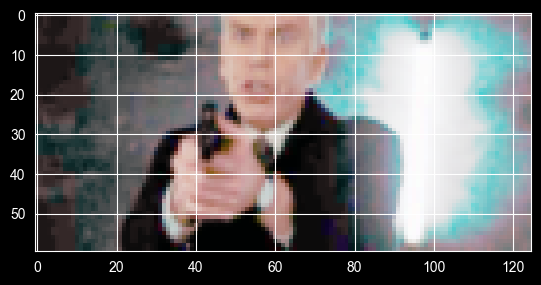

In [16]:
"""
A sanity check cell to verify the data pipeline.
It grabs a single batch from the training dataset and prints the shapes of the returned tensors (images, descriptions, etc.) to ensure everything is loaded correctly.
"""
#Modified
# Single sample check
sample = sp_train_dataset[np.random.randint(0,400)]
frames, image_target, roi1, roi2, roi_valid, roi_frame, ent_id, text_dict, obj_labels = sample


print("Description: ", image_target.shape)
figure, ax = plt.subplots(1,1)
show_image(ax, image_target)

# Do some tests on the batches (try with batch size small)
frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = next(iter(train_dataloader))
print(frames.shape)
print(descriptions.shape)

I will leave the test of the other datasets to you.

# **Chapter 2: Models**


---



We provide a simple text encoder based on a recurrent neural network (LSTM). Feel free to provide your own text encoder.

## 2.1 The NLP models

In [17]:
# @title The text autoencoder (Seq2Seq)
#Modified
class RobertaEncoder(nn.Module):
    def __init__(self, hidden_dim, num_layers=1, dropout=0.1, unfreeze_layers=4):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained("roberta-base")

        # Freeze everything
        for param in self.roberta.parameters():
            param.requires_grad = False

        # Unfreeze last N layers
        for layer in self.roberta.encoder.layer[-unfreeze_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

        # =========================
        # Attention Pooling (nonlinear)
        # =========================
        self.attn_pool = nn.Sequential(
            nn.Linear(self.roberta.config.hidden_size, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # =========================
        # Projection Head (512 → 256)
        # =========================
        self.projection = nn.Sequential(
            nn.Linear(self.roberta.config.hidden_size, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout),

            nn.Linear(256, hidden_dim)
        )

        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask=None):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        last_hidden = outputs.last_hidden_state  # (B, T, 768)

        # =========================
        # Attention Pooling
        # =========================
        attn_scores = self.attn_pool(last_hidden)  # (B, T, 1)

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1)
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        attn_weights = torch.softmax(attn_scores, dim=1)
        pooled_attn = torch.sum(attn_weights * last_hidden, dim=1)  # (B, 768)

        # =========================
        # CLS Token Fusion
        # =========================
        cls_token = last_hidden[:, 0]  # (B, 768)
        pooled = 0.7 * pooled_attn + 0.3 * cls_token

        # =========================
        # Projection
        # =========================
        latent = self.projection(pooled)

        # Final normalization
        latent = self.layer_norm(latent)
        latent = self.dropout(latent)

        # =========================
        # LSTM-compatible output
        # =========================
        hidden = latent.unsqueeze(0)  # (1, B, hidden_dim)
        cell = torch.zeros_like(hidden)

        return None, hidden, cell


class DecoderLSTM(nn.Module):
    """
      Decodes a latent space representation into a sequence of tokens.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.out = nn.Linear(hidden_dim, vocab_size) # Should be hidden_dim

    def forward(self, input_seq, hidden, cell):
        embedded = self.embedding(input_seq)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.out(output)
        return prediction, hidden, cell
#Modified
# We create the basic text autoencoder (a special case of a sequence to sequence model)
class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, input_seq, target_seq, attention_mask=None):
        # Pass keyword args to RobertaEncoder
        _enc_out, hidden, cell = self.encoder(
            input_ids=input_seq,      # ← Keyword arg!
            attention_mask=attention_mask
        )

        decoder_input = target_seq[:, :-1]
        predictions, _hidden, _cell = self.decoder(decoder_input, hidden, cell)
        return predictions

In [18]:
# @title Utility functions for NLP tasks
"""
1. `generate`: An inference function for the text decoder.
   - It performs autoregressive generation: predicting one token at a time and feeding it back as input for the next step.
   - Uses temperature scaling for sampling diversity.
"""

def generate(model, hidden, cell, max_len, sos_token_id, eos_token_id):
      """
        This function generates a sequence of tokens using the provided decoder.
      """
      # Ensure the model is in evaluation mode
      model.eval()

      # 2. SETUP DECODER INPUT
      # Start with the SOS token, shape (1, 1)
      dec_input = torch.tensor([[sos_token_id]], dtype=torch.long, device=device)
      # hidden = torch.zeros(1, 1, hidden_dim, device=device)
      # cell = torch.zeros(1, 1, hidden_dim, device=device)

      generated_tokens = []

      # 3. AUTOREGRESSIVE LOOP
      for _ in range(max_len):
          with torch.no_grad():
              # Run the decoder one step at a time
              # dec_input is (1, 1) here—it's just the last predicted token
              prediction, hidden, cell = model(dec_input, hidden, cell)

          logits = prediction.squeeze(1) # Shape (1, vocab_size)
          temperature = 0.9 # <--- Try a value between 0.5 and 1.0

          # 1. Divide logits by temperature
          # 2. Apply softmax to get probabilities
          # 3. Use multinomial to sample one token based on the probabilities
          probabilities = torch.softmax(logits / temperature, dim=-1)
          next_token = torch.multinomial(probabilities, num_samples=1)

          token_id = next_token.squeeze().item()

          # Check for the End-of-Sequence token
          if token_id == eos_token_id:
              break

          if token_id == 0 or token_id == sos_token_id:
              continue

            # Append the predicted token
          generated_tokens.append(token_id)

          # The predicted token becomes the input for the next iteration
          dec_input = next_token

      # Return the list of generated token IDs
      return generated_tokens

In [19]:
# @title Do some tests
"""
Manually testing the text generation capabilities of the model.
"""

# desc = text_dataset[np.random.randint(0, 100)]
# print(f"Input: {desc}")
# input_ids = tokenizer(desc, return_tensors="pt",  padding=True, truncation=True).input_ids
# input_ids = input_ids.to(device)
# generated_tokens = generate(model, hidden, cell, max_len=100, sos_token_id=tokenizer.cls_token_id, eos_token_id=tokenizer.sep_token_id)
# print("Output: ", tokenizer.decode(generated_tokens))

'\nManually testing the text generation capabilities of the model.\n'

## 2.2 The Vision models

In [20]:
# @title The visual autoencoder
"""
Defines the computer vision modules:
1. `Backbone`: A CNN that processes input images into feature maps.
2. `VisualEncoder`: Uses two backbones to separate 'content' and 'context' features, projecting them to a latent space.
3. `VisualDecoder`: Reconstructs images from the latent representation using Transposed Convolutions.
4. `VisualAutoencoder`: The container class for the encoder and decoder.
"""

class Backbone(nn.Module):
    """
      Main convolutional blocks for our CNN
    """
    def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
        super(Backbone, self).__init__()
        # Encoder convolutional layers
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 16, 7, stride=2, padding=3),
            nn.GroupNorm(8, 16),
            nn.LeakyReLU(0.1),

            nn.Conv2d(16, 32, 5, stride=2, padding=2),
            nn.GroupNorm(8, 32),
            nn.LeakyReLU(0.1),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.LeakyReLU(0.1),
        )

        # Calculate flattened dimension for linear layer
        self.flatten_dim = 64 * output_w * output_h
        # Latent space layers
        self.fc1 = nn.Sequential(nn.Linear(self.flatten_dim, latent_dim), nn.ReLU())


    def forward(self, x):
        x = self.encoder_conv(x)
        x = x.view(-1, self.flatten_dim)  # flatten for linear layer
        z = self.fc1(x)
        return z

class VisualEncoder(nn.Module):
    """
      Encodes an image into a latent space representation. Note the two pathways
      to try to disentangle the mean pattern from the image
    """
    def __init__(self, latent_dim=latent_dim, output_w = 8, output_h = 16):
        super(VisualEncoder, self).__init__()

        self.context_backbone = Backbone(latent_dim, output_w, output_h)
        self.content_backbone = Backbone(latent_dim, output_w, output_h)

        self.projection = nn.Linear(2*latent_dim, latent_dim)
    def forward(self, x):
        z_context = self.context_backbone(x)
        z_content = self.content_backbone(x)
        z = torch.cat((z_content, z_context), dim=1)
        z = self.projection(z)
        return z

class VisualDecoder(nn.Module):
    """
      Decodes a latent representation into a content image and a context image
    """
    def __init__(self, latent_dim=latent_dim, output_w = 8, output_h = 16):
        super(VisualDecoder, self).__init__()
        self.imh = 60
        self.imw = 125
        self.flatten_dim = 64 * output_w * output_h
        self.output_w = output_w
        self.output_h = output_h

        self.fc1 = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder_conv = nn.Sequential(
          nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(1,1)),
          nn.GroupNorm(8, 32),
          nn.LeakyReLU(0.1),

          nn.ConvTranspose2d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
          nn.GroupNorm(8, 16),
          nn.LeakyReLU(0.1),

          nn.ConvTranspose2d(16, 3, kernel_size=7, stride=2, padding=3, output_padding=(1, 1)),
          nn.Sigmoid() # Use nn.Tanh() if your data is normalized to [-1, 1]
      )

    def forward(self, z):
      x = self.fc1(z)

      x_content = self.decode_image(x)
      x_context = self.decode_image(x)

      return x_content, x_context

    def decode_image(self, x):
      x = x.view(-1, 64, self.output_w, self.output_h)      # reshape to conv feature map
      x = self.decoder_conv(x)
      x = x[:, :, :self.imh, :self.imw]          # crop to original size if needed
      return x

class VisualAutoencoder( nn.Module):
    def __init__(self, latent_dim=latent_dim, output_w = 8, output_h = 16):
        super(VisualAutoencoder, self).__init__()
        self.encoder = VisualEncoder(latent_dim, output_w, output_h)
        self.decoder = VisualDecoder(latent_dim, output_w, output_h)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## 2.3 The main architecture


In [21]:
# @title A simple attention architecture
"""
Defines an `Attention` module.
It computes attention weights over a sequence of RNN outputs to create a context vector, helping the model focus on relevant parts of the input sequence.
"""

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        # This "attention" layer learns a query vector
        self.attn = nn.Linear(hidden_dim, 1)
        self.softmax = nn.Softmax(dim=1) # Over the sequence length

    def forward(self, rnn_outputs):
        # rnn_outputs shape: [batch, seq_len, hidden_dim]

        # Pass through linear layer to get "energy" scores
        energy = self.attn(rnn_outputs).squeeze(2) # Shape: [batch, seq_len]

        # Get attention weights
        attn_weights = self.softmax(energy) # Shape: [batch, seq_len]

        # Apply weights
        # attn_weights.unsqueeze(1) -> [batch, 1, seq_len]
        # bmm with rnn_outputs -> [batch, 1, hidden_dim]
        context = torch.bmm(attn_weights.unsqueeze(1), rnn_outputs)

        # Squeeze to get final context vector
        return context.squeeze(1), attn_weights # Return both context and attention weights

In [22]:
text_encoder = RobertaEncoder(hidden_dim=latent_dim)
text_decoder = DecoderLSTM(vocab_size=tokenizer.vocab_size,
                          embedding_dim=emb_dim,
                          hidden_dim=latent_dim)

text_autoencoder = Seq2SeqLSTM(text_encoder, text_decoder)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3915.67it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
# @title The main sequence predictor model
"""
This is the core architecture `SequencePredictor`.
1. **Encoders**: Uses the `image_encoder` and `text_encoder` to process the sequence of 4 input frames and descriptions.
2. **Temporal Fusion**: A GRU processes the sequence of fused (image+text) embeddings to capture temporal dynamics.
3. **Attention**: Applies attention over the sequence to summarize context.
4. **Decoders**: Predicts the *next* (5th) frame's image and text using `image_decoder` and `text_decoder`.
"""
#Modified
class SequencePredictor(nn.Module):
    def __init__(self, visual_autoencoder, text_autoencoder, latent_dim, gru_hidden_dim):
        super(SequencePredictor, self).__init__()

        # --- 1. Static Encoders ---
        self.image_encoder = visual_autoencoder.encoder
        self.text_encoder = text_autoencoder.encoder  # This is HuggingFace RobertaModel

        # --- 2. Temporal Encoder ---
        fusion_dim = latent_dim * 2  # z_visual + z_text
        self.temporal_rnn = nn.GRU(fusion_dim, latent_dim, batch_first=True)

        # --- 3. Attention ---
        self.attention = Attention(gru_hidden_dim)

        # --- 4. Final Projection ---
        self.projection = nn.Sequential(
            nn.Linear(gru_hidden_dim * 2, latent_dim),
            nn.ReLU()
        )

        # --- 5. Decoders ---
        self.image_decoder = visual_autoencoder.decoder
        self.text_decoder = text_autoencoder.decoder

        # For initializing decoder hidden/cell
        self.fused_to_h0 = nn.Linear(latent_dim, latent_dim)
        self.fused_to_c0 = nn.Linear(latent_dim, latent_dim)

    def forward(self, image_seq, input_ids_text_encoder, attention_mask_text_encoder, target_seq_text_decoder):
        batch_size, seq_len, C, H, W = image_seq.shape

        # --- 1. Image Encoder ---
        img_flat = image_seq.view(batch_size * seq_len, C, H, W)
        z_v_flat = self.image_encoder(img_flat)  # [b*s, latent_dim]
        z_v_seq = z_v_flat.view(batch_size, seq_len, -1)  # [b, s, latent]

        # --- 2. Text Encoder with attention mask and roberta model---
        # FIX: Call self.text_encoder directly and use the appropriate input_ids/attention_mask
        # The RobertaEncoder's forward returns (None, hidden, cell)
        _, hidden_roberta, cell_roberta = self.text_encoder(
            input_ids=input_ids_text_encoder, # Using the argument for RoBERTa input
            attention_mask=attention_mask_text_encoder
        )
        # z_t_seq now represents the latent of the *first* frame's description text for each batch item
        z_t_seq = hidden_roberta.squeeze(0)   # (batch, latent_dim)
        z_t_flat = z_t_seq.unsqueeze(1).repeat(1, seq_len, 1).view(-1, z_t_seq.size(-1))

        # --- 3. Fusion for temporal RNN ---
        z_fusion_flat = torch.cat((z_v_flat, z_t_flat), dim=1)
        z_fusion_seq = z_fusion_flat.view(batch_size, seq_len, -1)

        zseq, h = self.temporal_rnn(z_fusion_seq)
        h = h.squeeze(0)

        # --- 4. Attention ---
        context, attn_weights = self.attention(zseq) # Capture attention weights here

        # --- 5. Final latent for decoders ---
        z = self.projection(torch.cat((h, context), dim=1))

        # --- 6. Image decoding ---
        pred_image_content, pred_image_context = self.image_decoder(z)

        # --- 7. Text decoding (teacher forcing) ---
        h0 = self.fused_to_h0(z).unsqueeze(0)
        c0 = self.fused_to_c0(z).unsqueeze(0)


        decoder_input_for_lstm = target_seq_text_decoder # Direct use of the target sequence

        predicted_text_logits_k, _hidden, _cell = self.text_decoder(decoder_input_for_lstm, h0, c0)

        # Return h0, c0 for generation in validation
        # Include attn_weights in the return
        return pred_image_content, pred_image_context, predicted_text_logits_k, h0, c0, z_v_seq, z_t_seq, attn_weights

# **Chapter 3: Training routines**


---




In [24]:
# @title Training utility functions: To initialize and to visualize the progress
"""
1. `init_weights`: Initializes neural network weights using Kaiming Normal initialization.
2. `validation`: A visualization routine. It runs the model on a validation batch and plots:
   - The 4 input frames and their descriptions.
   - The target (Ground Truth) frame and description.
   - The model's predicted frame and generated text description.
"""

def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.constant_(m.bias, 0)

#Modified
# Plots four images and their reconstructions
def validation( model, data_loader ):
  model.eval()
  with torch.no_grad():
    # Unpack 9 values from the DataLoader output
    frames, image_target_val, roi1, roi2, roi_valid, roi_frame, ent_id, text_dict_val, obj_labels = next(iter(data_loader))

    # Move tensors to device
    frames = frames.to(device)
    image_target_val = image_target_val.to(device)

    # Unpack text inputs for the model
    input_ids_roberta_val = text_dict_val["input_ids"].to(device)
    attention_mask_roberta_val = text_dict_val["attention_mask"].to(device)
    decoder_input_lstm_val = text_dict_val["decoder_input_ids"].to(device)
    target_ids_val = text_dict_val["target_ids"].to(device)

    # Call SequencePredictor with corrected arguments
    predicted_image_content, predicted_image_context, predicted_text_logits_k, h0_dec, c0_dec, _, _, _ = model(
        frames,
        input_ids_roberta_val,
        attention_mask_roberta_val,
        decoder_input_lstm_val
    )

    figure, ax = plt.subplots(2, 6, figsize=(20, 5), gridspec_kw={'height_ratios': [2, 1.5]})

    # Display input frames
    for i in range(4):
      im = frames[0, i, :, :, :].cpu()
      show_image(ax[0,i], im )
      ax[0,i].set_aspect('auto')
      ax[0,i].axis('off')

      # Display description for the input frames, as text_dict_val contains only its text
      wrapped_text = textwrap.fill(tokenizer.decode(text_dict_val['input_ids'][0, i, :], skip_special_tokens=True), width=40)
      ax[1,i].text(
                0.5, 0.99,
                wrapped_text,
                ha='center',
                va='top',
                fontsize=10,
                wrap=True
            )
      ax[1,i].axis('off') # Hide axes for the text subplot

    # Display target image
    show_image(ax[0,4], image_target_val[0].cpu())
    ax[0,4].set_title('Target')
    ax[0,4].set_aspect('auto')
    ax[0,4].axis('off')

    # Display target text
    wrapped_text = textwrap.fill(tokenizer.decode(target_ids_val[0], skip_special_tokens=True), width=40)
    ax[1,4].text(
            0.5, 0.99,
            wrapped_text,
            ha='center',
            va='top',
            fontsize=10,
            wrap=False)
    ax[1,4].axis('off')

    # Display predicted image
    output = predicted_image_context[0, :, :, :].cpu()
    show_image(ax[0,5], output)
    ax[0,5].set_title('Predicted')
    ax[0,5].set_aspect('auto')
    ax[0,5].axis('off')

    # Generate and display predicted text (using h0_dec and c0_dec from model output)
    generated_tokens = generate(model.text_decoder,
                                h0_dec[:,0, :].unsqueeze(1),
                                c0_dec[:, 0, :].unsqueeze(1),
                                max_len=150,
                                sos_token_id=tokenizer.cls_token_id,
                                eos_token_id=tokenizer.sep_token_id)

    wrapped_text = textwrap.fill(tokenizer.decode(generated_tokens), width=40)

    ax[1,5].text(
            0.5, 0.99,
            wrapped_text,
            ha='center',
            va='top',
            fontsize=10,
            wrap=False )
    ax[1,5].axis('off')
    plt.tight_layout()
    plt.show()

## 3.1 Initialization and setup

In [25]:
# @title Variables and initial setup
"""
Global setup:
- Sets the computation device (CUDA/CPU).
- Defines hyperparameters: `N_EPOCHS`, `emb_dim`, `latent_dim`, etc.
"""

torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from final_training import (N_EPOCHS, emb_dim, latent_dim, num_layers, lr, max_seq_len, batch_size, dropout)
N_EPOCHS = N_EPOCHS
emb_dim = emb_dim
latent_dim = latent_dim
num_layers = num_layers
lr = lr
max_seq_len = max_seq_len
batch_size = batch_size
dropout = True

In [26]:
# @title Initializing the NLP models
"""
1. Instantiates the `RobertaEncoder`, `DecoderLSTM`, and `Seq2SeqLSTM`.
2. Loads pre-trained weights from Google Drive (`text_autoencoder.pth`).
3. Freezes the text autoencoder parameters to keep them fixed during the main training phase.
"""

encoder = RobertaEncoder(hidden_dim=latent_dim).to(device)
decoder = DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
text_autoencoder = Seq2SeqLSTM(encoder, decoder).to(device)
#text_autoencoder, _, _, _ = load_checkpoint(text_autoencoder, None, filename='text_autoencoder.pth')


# Deactivating training from this model for efficiency (although not ideal)
#for param in text_autoencoder.parameters():
        #param.requires_grad = True

trainable_params = sum(p.numel() for p in text_autoencoder.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in text_autoencoder.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2006.96it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 30641706
Total params: 126935850


In [27]:
# @title Initializing visual models
"""
1. Instantiates the `VisualAutoencoder`.
2. Applies the custom weight initialization.
"""

visual_autoencoder = VisualAutoencoder(latent_dim=latent_dim)
visual_autoencoder.apply(init_weights)

total_params = sum(p.numel() for p in visual_autoencoder.parameters() if p.requires_grad)
print(f"Total trainable parameters in visual autoencoder: {total_params}")

Total trainable parameters in visual autoencoder: 503539


In [28]:
# @title Initialize the main architecture
"""
Instantiates the full `SequencePredictor` model, wiring together the visual encoder, text encoder, and the sequence modeling components.
Prints the total number of parameters.
"""

# We put all the sizes the same, not ideal as well
sequence_predictor = SequencePredictor(visual_autoencoder, text_autoencoder, latent_dim, latent_dim)
sequence_predictor.to(device)
sequence_predictor.text_decoder = text_autoencoder.decoder # Fix for text_decoder
# # Print number of trainable parameters
total_params = sum(p.numel() for p in sequence_predictor.parameters() if p.requires_grad)
print(f"Total trainable parameters in the whole model: {total_params}")

# Print model size
total_params = sum(p.numel() for p in sequence_predictor.parameters())
print(f"Total parameters: {total_params}")

Total trainable parameters in the whole model: 31148734
Total parameters: 127442878


In [29]:
dummy_input = torch.randint(0, tokenizer.vocab_size, (batch_size, max_seq_len)).to(device)
dummy_mask = torch.ones((batch_size, max_seq_len)).to(device)  # all tokens "valid"

print("===== Roberta Text Autoencoder Summary =====")

summary(
    text_autoencoder,
    input_data=(dummy_input, dummy_input, dummy_mask),  #
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3
)

===== Roberta Text Autoencoder Summary =====


Layer (type:depth-idx)                                            Input Shape               Output Shape              Param #                   Trainable
Seq2SeqLSTM                                                       [4, 120]                  [4, 119, 50265]           --                        Partial
├─RobertaEncoder: 1-1                                             --                        --                        --                        Partial
│    └─RobertaModel: 2-1                                          --                        [4, 768]                  --                        Partial
│    │    └─RobertaEmbeddings: 3-1                                --                        [4, 120, 768]             (39,000,576)              False
│    │    └─RobertaEncoder: 3-2                                   [4, 120, 768]             [4, 120, 768]             85,054,464                Partial
│    │    └─RobertaPooler: 3-3                                    [4, 120, 768]         

In [30]:
# 3-channel RGB image, 64x64 resolution
dummy_image = torch.randn(batch_size, 3, 64, 64).to(device)

print("===== CNN Visual Autoencoder Summary =====")
summary(
    visual_autoencoder,
    input_data=dummy_image,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3
)

===== CNN Visual Autoencoder Summary =====


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VisualAutoencoder                        [4, 3, 64, 64]            [2, 3, 60, 125]           --                        True
├─VisualEncoder: 1-1                     [4, 3, 64, 64]            [2, 16]                   --                        True
│    └─Backbone: 2-1                     [4, 3, 64, 64]            [2, 16]                   --                        True
│    │    └─Sequential: 3-1              [4, 3, 64, 64]            [4, 64, 8, 8]             33,920                    True
│    │    └─Sequential: 3-2              [2, 8192]                 [2, 16]                   131,088                   True
│    └─Backbone: 2-2                     [4, 3, 64, 64]            [2, 16]                   --                        True
│    │    └─Sequential: 3-3              [4, 3, 64, 64]            [4, 64, 8, 8]             33,920                    True
│  

## 3.2 Training loops

In [31]:
# @title Training tools
"""
Sets up the optimization process:
1. `criterion_images`: L1 Loss for image reconstruction.
2. `criterion_ctx`: MSE Loss for context guidance (mean color).
3. `criterion_text`: CrossEntropy Loss for text generation.
4. `optimizer`: Adam optimizer for updating model weights.
"""

criterion_images = nn.L1Loss()
criterion_ctx = nn.MSELoss()
criterion_text = nn.CrossEntropyLoss(ignore_index=tokenizer.convert_tokens_to_ids(tokenizer.pad_token))
optimizer = torch.optim.Adam(sequence_predictor.parameters(), lr=lr)

In [32]:
# Project Evaluation + BLEU


def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0
    bleu_scores = []

    with torch.no_grad():
        for batch in dataloader:
            # --- Unpack batch ---
            frames, image_target, roi1, roi2, roi_valid, roi_frame, ent_id, text_dict, obj_labels = batch
            frames = frames.to(device)
            image_target = image_target.to(device)
            roi1 = roi1.to(device)
            roi2 = roi2.to(device)
            roi_valid = roi_valid.to(device)
            roi_frame = roi_frame.to(device)

            input_ids_roberta = text_dict["input_ids"].to(device)
            attention_mask_roberta = text_dict['attention_mask'].to(device)
            decoder_input_lstm = text_dict["decoder_input_ids"].to(device)
            target_ids_lstm = text_dict["target_ids"].to(device)

            # --- Forward pass ---
            _, _, predicted_text_logits_k, *_ = model(
                frames,
                input_ids_roberta,
                attention_mask_roberta,
                decoder_input_lstm
            )

            # --- Text loss ---
            prediction_flat = predicted_text_logits_k.reshape(-1, tokenizer.vocab_size)
            target_flat = target_ids_lstm.reshape(-1)
            loss_text = criterion_text(prediction_flat, target_flat)
            total_loss += loss_text.item()

            # --- BLEU ---
            preds = torch.argmax(predicted_text_logits_k, dim=-1)
            for pred, tgt in zip(preds, target_ids_lstm):
                pred_text = tokenizer.decode(pred, skip_special_tokens=True)
                tgt_text = tokenizer.decode(tgt, skip_special_tokens=True)
                bleu = sentence_bleu([tgt_text.split()], pred_text.split())
                bleu_scores.append(bleu)

    return {
        "text_loss": total_loss / len(dataloader),
        "bleu": sum(bleu_scores) / len(bleu_scores)
    }


# Save predictions
def save_predictions(model, dataloader, num_samples=5):
    model.eval()
    samples = []

    with torch.no_grad():
        for batch in dataloader:
            frames, image_target, roi1, roi2, roi_valid, roi_frame, ent_id, text_dict, obj_labels = batch
            frames = frames.to(device)

            decoder_input_lstm = text_dict["decoder_input_ids"].to(device)
            target_ids_lstm = text_dict["target_ids"].to(device)

            _, _, predicted_text_logits_k, *_ = model(
                frames,
                text_dict["input_ids"].to(device),
                text_dict["attention_mask"].to(device),
                decoder_input_lstm
            )

            preds = torch.argmax(predicted_text_logits_k, dim=-1)

            for i in range(len(preds)):
                pred_text = tokenizer.decode(preds[i], skip_special_tokens=True)
                tgt_text = tokenizer.decode(target_ids_lstm[i], skip_special_tokens=True)

                samples.append({
                    "ground_truth": tgt_text,
                    "prediction": pred_text
                })

                if len(samples) >= num_samples:
                    return samples
    return samples

# Plot loss
def plot_loss_curve(losses):
    plt.figure()
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Roberta + CNN Training Loss")
    plt.savefig("Roberta+CNN_loss_curve.png")
    plt.close()


# BLEU bar chart
def plot_bleu(bleu_score):
    plt.figure()
    plt.bar(["Roberta+CNN"], [bleu_score])
    plt.ylabel("BLEU Score")
    plt.title("Roberta + CNN BLEU")
    plt.savefig("Roberta + CNN_bleu.png")
    plt.close()


# Figure 3
def save_prediction_examples(model, dataloader, n_samples=5):
    model.eval()
    examples = []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= n_samples:
                break

            # --- Correct unpack ---
            frames, image_target, roi1, roi2, roi_valid, roi_frame, ent_id, text_dict, obj_labels = batch

            frames = frames.to(device)
            image_target = image_target.to(device)

            input_ids = text_dict["input_ids"].to(device)
            attention_mask = text_dict["attention_mask"].to(device)
            decoder_input = text_dict["decoder_input_ids"].to(device)
            target_ids = text_dict["target_ids"].to(device)

            # --- Forward ---
            pred_image, _, pred_text_logits, *_ = model(
                frames,
                input_ids,
                attention_mask,
                decoder_input
            )

            pred_tokens = pred_text_logits.argmax(dim=-1)

            gt_text = tokenizer.decode(target_ids[0], skip_special_tokens=True)
            pred_text = tokenizer.decode(pred_tokens[0], skip_special_tokens=True)

            examples.append({
                "input_frames": frames[0].cpu().tolist(),
                "ground_truth_image": image_target[0].cpu().tolist(),
                "predicted_image": pred_image[0].cpu().tolist(),
                "ground_truth_text": gt_text,
                "predicted_text": pred_text
            })

    return examples
# Figure 4
def plot_attention_heatmaps(model, dataloader, device, n_samples=3, save_dir="figures"):
    """
    - Shows n_samples individual attention maps (one per batch sample)
    - Shows an averaged attention map across batch for general trends
    - Saves all plots as PNGs
    """
    model.eval()
    sample_count = 0
    all_attn_maps = []

    os.makedirs(save_dir, exist_ok=True)

    with torch.no_grad():
        for batch in dataloader:
            if sample_count >= n_samples:
                break

            # --- Correct unpack ---
            frames, image_target, roi1, roi2, roi_valid, roi_frame, ent_id, text_dict, obj_labels = batch

            frames = frames.to(device)
            input_ids = text_dict["input_ids"].to(device)
            attention_mask = text_dict["attention_mask"].to(device)
            decoder_input = text_dict["decoder_input_ids"].to(device)

            # --- Forward ---
            _, _, _, attn_weights, *_ = model(
                frames,
                input_ids,
                attention_mask,
                decoder_input
            )

            batch_size = attn_weights.size(0)

            # --- Individual maps ---
            for b in range(batch_size):
                if sample_count >= n_samples:
                    break

                attn_map = attn_weights[b].detach().cpu().numpy()

                title = f"Attention_Heatmap_Sample_{sample_count}"

                plt.figure(figsize=(6,5))
                plt.imshow(attn_map, cmap='viridis', aspect='auto')
                plt.title(title)
                plt.xlabel("Input tokens/frames")
                plt.ylabel("Output tokens/frames")
                plt.colorbar()

                save_path = os.path.join(save_dir, f"{title}.png")
                plt.savefig(save_path, bbox_inches='tight', dpi=300)
                plt.show()

                plt.close()
                print(f"Saved: {save_path}")

                sample_count += 1

            all_attn_maps.append(attn_weights)

    # --- Average heatmap ---
    if all_attn_maps:
        all_attn_tensor = torch.cat(all_attn_maps, dim=0)
        avg_attn = all_attn_tensor.mean(dim=0)
        avg_attn_map = avg_attn.detach().cpu().numpy()

        title = f"Average_Attention_Map_{len(all_attn_tensor)}_Samples"

        plt.figure(figsize=(6,5))
        plt.imshow(avg_attn_map, cmap='viridis', aspect='auto')
        plt.title(title)
        plt.xlabel("Input tokens/frames")
        plt.ylabel("Output tokens/frames")
        plt.colorbar()

        save_path = os.path.join(save_dir, f"{title}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()

        plt.close()
        print(f"Saved: {save_path}")

In [33]:
# Grab one batch from the DataLoader
batch = next(iter(train_dataloader))

# Check the type of the batch
print(type(batch))

# If it's a tuple or list, check its length
if isinstance(batch, (tuple, list)):
    print("Batch length:", len(batch))
    for i, b in enumerate(batch):
        print(f"Item {i} type:", type(b))
        # If it's a tensor, print its shape
        if isinstance(b, torch.Tensor):
            print(f"  Shape: {b.shape}")
        # If it's a dict, print the keys and shapes
        elif isinstance(b, dict):
            print("  Keys:", b.keys())
            for k, v in b.items():
                print(f"    {k}: {v.shape}")
else:
    # If batch is a single tensor/dict
    print("Single item batch type:", type(batch))
    if isinstance(batch, dict):
        print("Keys:", batch.keys())
        for k, v in batch.items():
            print(f"  {k}: {v.shape}")

<class 'list'>
Batch length: 9
Item 0 type: <class 'torch.Tensor'>
  Shape: torch.Size([4, 4, 3, 60, 125])
Item 1 type: <class 'torch.Tensor'>
  Shape: torch.Size([4, 3, 60, 125])
Item 2 type: <class 'torch.Tensor'>
  Shape: torch.Size([4, 3, 60, 125])
Item 3 type: <class 'torch.Tensor'>
  Shape: torch.Size([4, 3, 60, 125])
Item 4 type: <class 'torch.Tensor'>
  Shape: torch.Size([4])
Item 5 type: <class 'torch.Tensor'>
  Shape: torch.Size([4])
Item 6 type: <class 'torch.Tensor'>
  Shape: torch.Size([4, 1])
Item 7 type: <class 'dict'>
  Keys: dict_keys(['input_ids', 'attention_mask', 'decoder_input_ids', 'target_ids'])
    input_ids: torch.Size([4, 120])
    attention_mask: torch.Size([4, 120])
    decoder_input_ids: torch.Size([4, 119])
    target_ids: torch.Size([4, 119])
Item 8 type: <class 'list'>


In [34]:
x = text_dataset[0]
print(type(x))
print(x.keys() if isinstance(x, dict) else len(x))

<class 'dict'>
dict_keys(['input_ids', 'attention_mask', 'decoder_input_ids', 'target_ids'])


C:\Users\dell 5590 i7\AppData\Local\Temp\ipykernel_21048\913164394.py:153: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  f"reid={float(loss_reid):.3f}, g_mse={float(loss_ground_mse):.3f}, "


Epoch [1/5] Loss: 7.3203  (im=0.228, ctx=0.023, txt=6.111, reid=0.000, g_mse=0.002, nce=0.000, entpool=0.000)


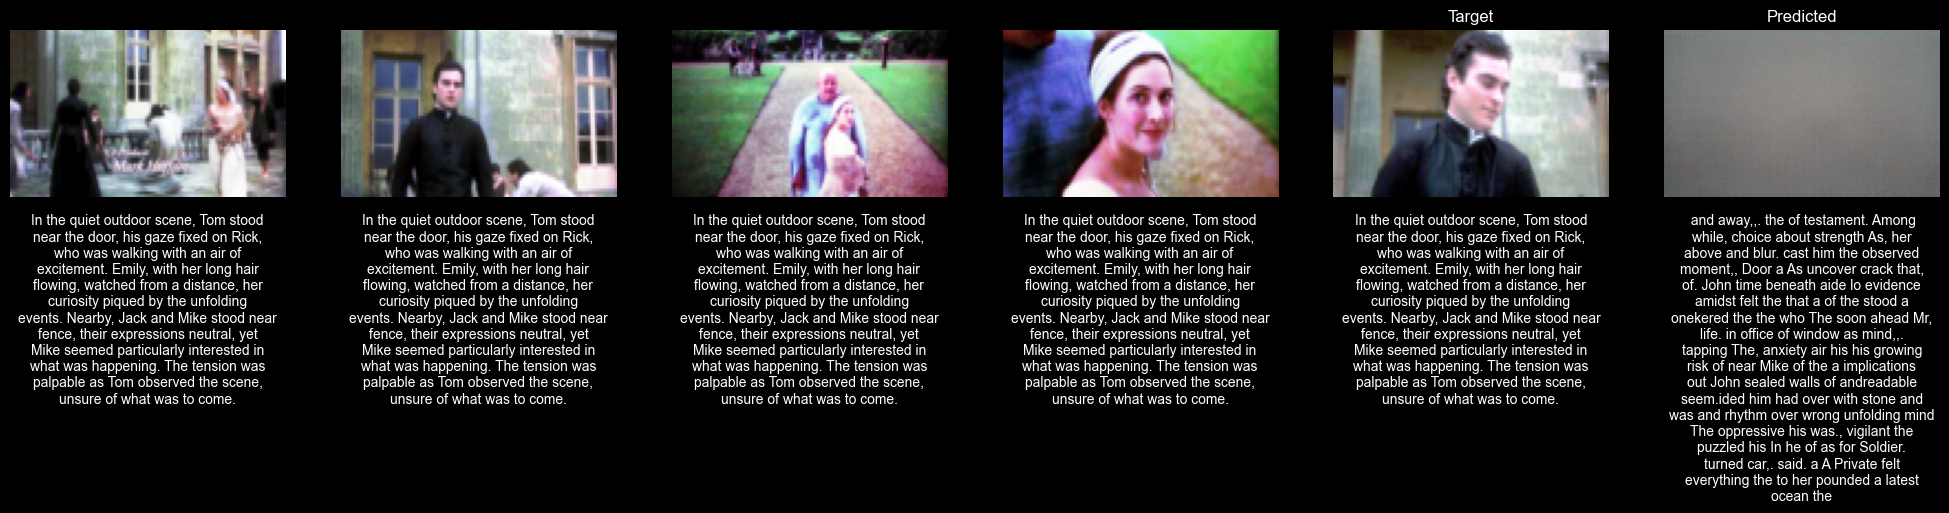

Epoch [2/5] Loss: 6.3769  (im=0.249, ctx=0.009, txt=6.124, reid=0.000, g_mse=0.000, nce=0.000, entpool=0.000)


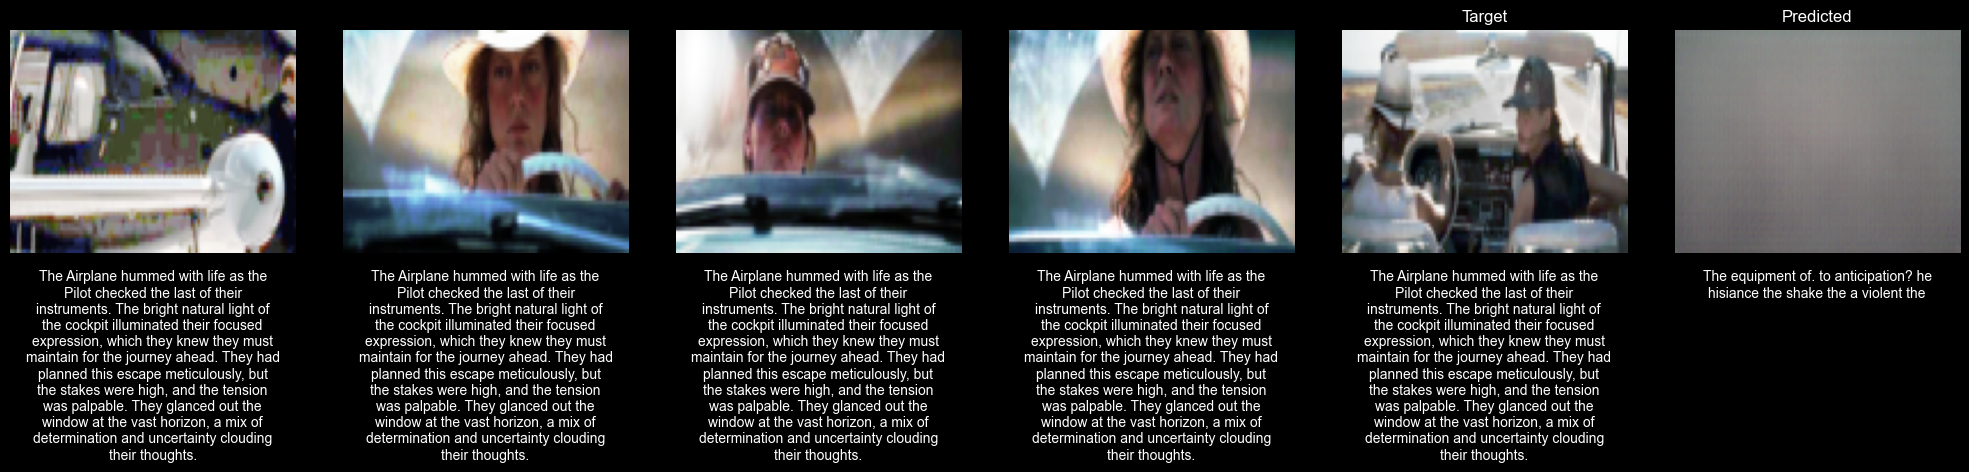

Epoch [3/5] Loss: 6.0781  (im=0.261, ctx=0.030, txt=5.133, reid=0.000, g_mse=0.012, nce=0.000, entpool=0.000)


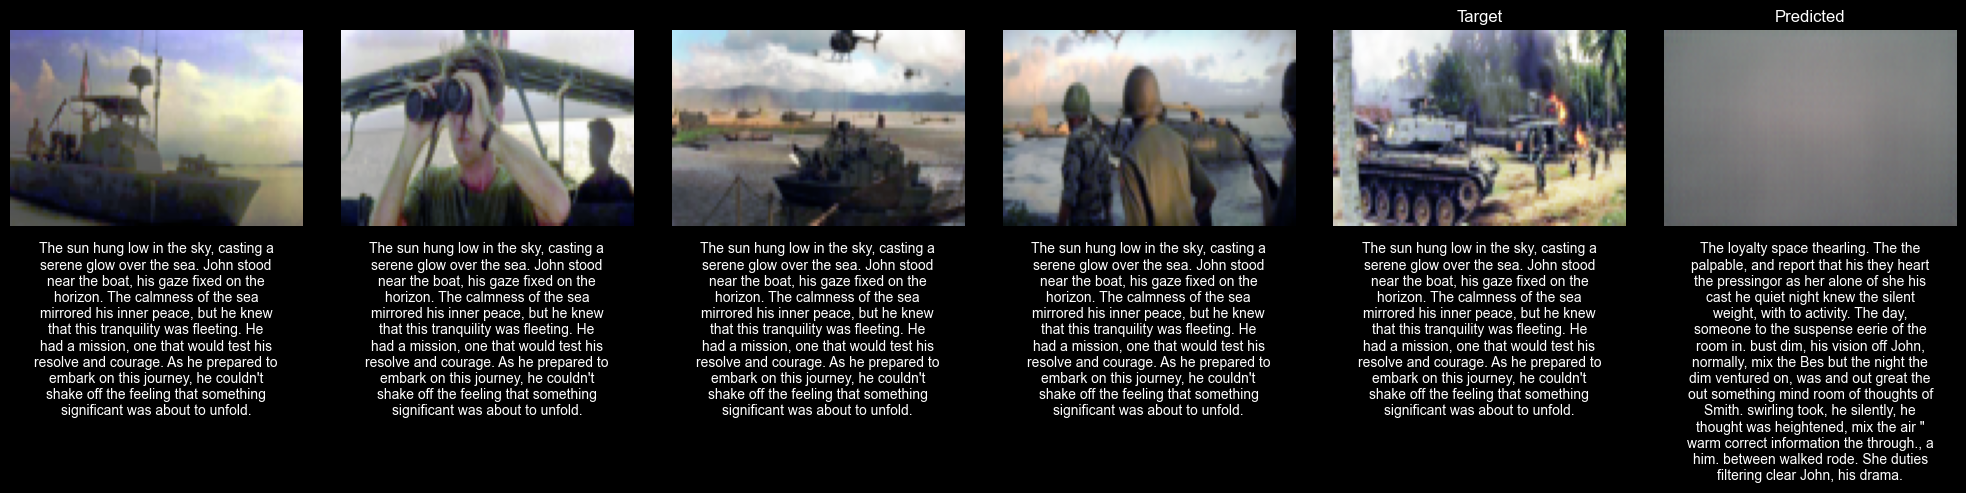

Epoch [4/5] Loss: 5.8108  (im=0.233, ctx=0.022, txt=4.703, reid=0.000, g_mse=0.000, nce=0.000, entpool=0.000)


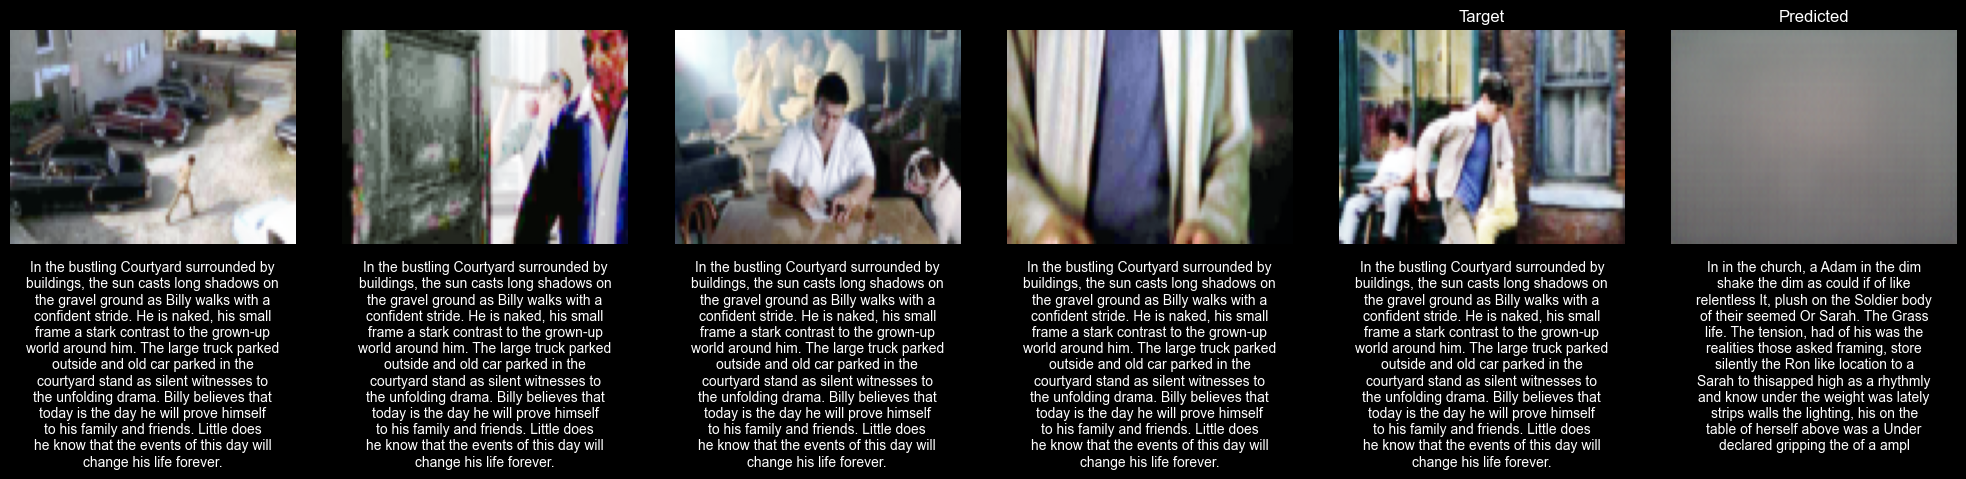

Epoch [5/5] Loss: 5.5629  (im=0.265, ctx=0.042, txt=5.733, reid=0.000, g_mse=0.000, nce=0.000, entpool=0.000)


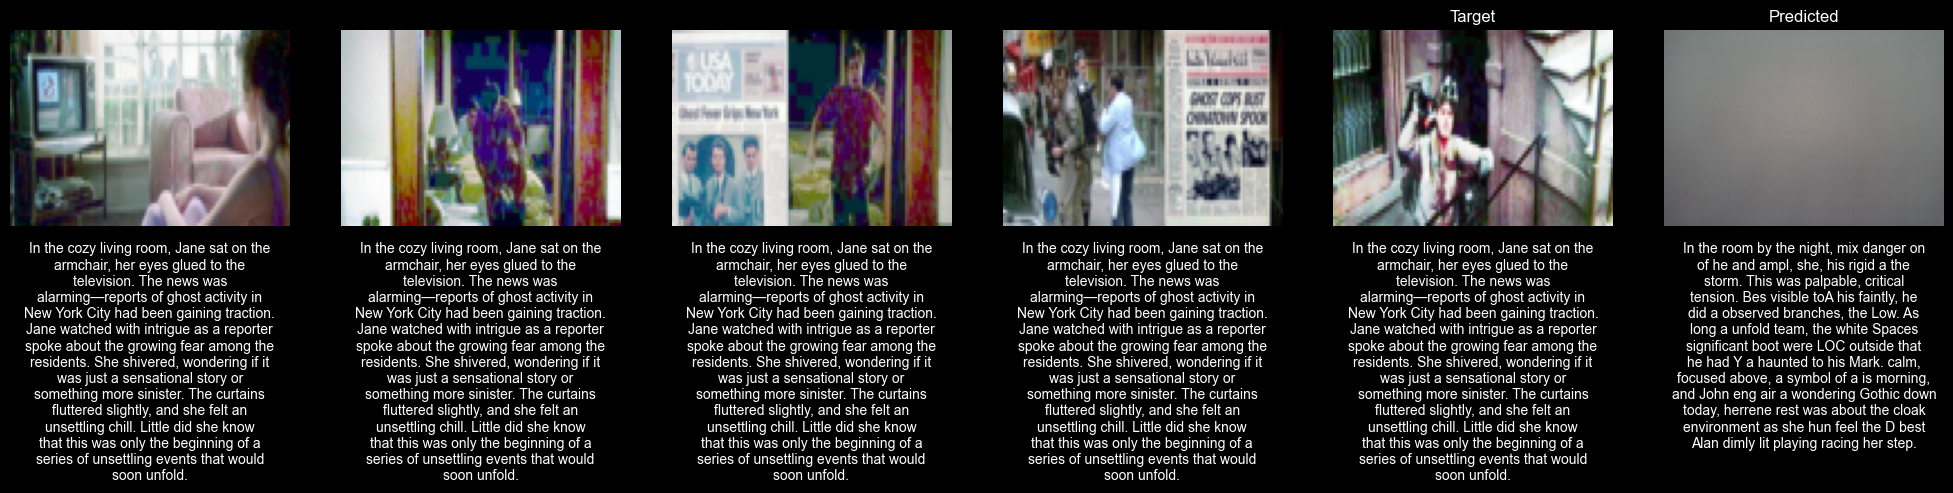

In [35]:
# @title Training loop for the sequence predictor
"""
The main training loop:
1. Iterates over epochs and batches.
2. Performs the forward pass to get predictions and latent representations.
3. Computes the **Base Losses**: Image L1, Context MSE, Text CrossEntropy.
4. Computes **CoT Grounding Losses** (if data is valid):
   - `loss_reid`: Visual consistency for re-identified entities.
   - `loss_ground_mse`: Embedding alignment between ROI and text.
   - `loss_contrast`: Contrastive loss for ROI-Text alignment.
   - `loss_entity_pool`: Consistency within the batch for the same entity.
5. Backpropagates total loss and updates weights.
6. Runs the validation visualization at the end of each epoch.
"""

# Instantiate the model, define loss and optimizer

# --- CoT-loss weights (added) ---
LAMBDA_REID = 0.10            # pulls same-entity ROIs together (student idea)
LAMBDA_GROUND_MSE = 0.10      # Option 2: frame-aware ROI↔text MSE grounding
LAMBDA_CONTRAST = 0.10        # Option 1: contrastive ROI↔text grounding (InfoNCE)
LAMBDA_ENTITY_POOL = 0.05     # Option 3: within-batch entity pooling loss

# Modified


sequence_predictor.train()
losses = []

for epoch in range(N_EPOCHS):
    running_loss = 0.0

    for batch in train_dataloader:
        # --- Unpack batch ---
        # Adjust indices to match your dataloader
        # Here, last item is text dict from TextTaskDataset
        frames, image_target, roi1, roi2, roi_valid, roi_frame, ent_id, text_dict, obj_labels = batch


        # --- Move tensors to device ---
        frames = frames.to(device)
        image_target = image_target.to(device)
        roi1 = roi1.to(device)
        roi2 = roi2.to(device)
        roi_valid = roi_valid.to(device)
        roi_frame = roi_frame.to(device)

        # Extract text inputs from text_dict
        input_ids_roberta = text_dict["input_ids"].to(device)
        attention_mask_roberta = text_dict['attention_mask'].to(device)
        decoder_input_lstm = text_dict["decoder_input_ids"].to(device)
        target_ids_lstm = text_dict["target_ids"].to(device)

        optimizer.zero_grad()

        # --- Forward pass ---
        pred_image_content, pred_image_context, predicted_text_logits_k, h0_dec, c0_dec, z_v_seq, z_t_seq, attn_weights = sequence_predictor(
            frames,
            input_ids_roberta,
            attention_mask_roberta,
            decoder_input_lstm
        )

        # -------------------------
        # Base losses
        # -------------------------
        loss_im = criterion_images(pred_image_content, image_target)

        mu_global = frames.mean(dim=[0, 1])
        mu_global = mu_global.unsqueeze(0).expand_as(pred_image_context)
        loss_context = criterion_ctx(pred_image_context, mu_global)

        prediction_flat = predicted_text_logits_k.reshape(-1, tokenizer.vocab_size)
        target_labels = target_ids_lstm.reshape(-1) # Use target_ids_lstm for loss
        loss_text = criterion_text(prediction_flat, target_labels)

        # -------------------------
        # CoT-based grounding losses
        # -------------------------
        loss_reid = torch.tensor(0.0, device=device)
        loss_ground_mse = torch.tensor(0.0, device=device)
        loss_contrast = torch.tensor(0.0, device=device)
        loss_entity_pool = torch.tensor(0.0, device=device)

        if roi_valid.any():
            mask = roi_valid.bool()
            if mask.sum() > 0:
                z_r1 = sequence_predictor.image_encoder(roi1[mask])
                z_r2 = sequence_predictor.image_encoder(roi2[mask])

                # ReID grounding
                loss_reid = F.mse_loss(z_r1, z_r2)

                # Frame-aware grounding
                if USE_FRAME_AWARE_GROUNDING:
                    z_t_match = z_t_seq[mask] # Use the global text embedding for the batch items that have valid ROIs
                    loss_ground_mse = F.mse_loss(z_r1, z_t_match)

                # Contrastive ROI↔text grounding
                if USE_CONTRASTIVE_ROI:
                    z_img = F.normalize(z_r1, dim=-1)
                    z_txt = F.normalize(z_t_match, dim=-1) # z_t_match from above
                    logits = (z_img @ z_txt.t()) / CONTRASTIVE_TAU
                    labels = torch.arange(logits.size(0), device=device)
                    loss_contrast = F.cross_entropy(logits, labels)

                # Entity pooling
                if USE_ENTITY_POOLING:

                    if isinstance(ent_id, list) and all(isinstance(e, str) for e in ent_id): # Check if ent_id is actually a list of strings
                        ent_list = [ent_id[i] for i, m in enumerate(mask.detach().cpu().tolist()) if m]
                        uniq = {}
                        for i_e, eid in enumerate(ent_list):
                            if not eid: # Empty string IDs are ignored
                                continue
                            uniq.setdefault(eid, []).append(i_e)

                        if len(uniq) > 0:
                            pool_losses = []
                            for eid, idxs in uniq.items():
                                if len(idxs) < 2:
                                    continue
                                group = z_r1[idxs]
                                mean = group.mean(dim=0, keepdim=True)
                                pool_losses.append(F.mse_loss(group, mean.expand_as(group)))
                            if len(pool_losses) > 0:
                                loss_entity_pool = torch.stack(pool_losses).mean()


        # -------------------------
        # Total loss
        # -------------------------
        loss = loss_im + loss_context + loss_text
        loss += LAMBDA_REID * loss_reid
        loss += LAMBDA_GROUND_MSE * loss_ground_mse
        loss += LAMBDA_CONTRAST * loss_contrast
        loss += LAMBDA_ENTITY_POOL * loss_entity_pool

        # Backprop
        loss.backward()
        # Gradient clipping
        from src.final_training import apply_gradient_clipping
        apply_gradient_clipping(sequence_predictor)
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_dataloader)
    losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{N_EPOCHS}] Loss: {epoch_loss:.4f}  "
        f"(im={loss_im.item():.3f}, ctx={loss_context.item():.3f}, txt={loss_text.item():.3f}, "
        f"reid={float(loss_reid):.3f}, g_mse={float(loss_ground_mse):.3f}, "
        f"nce={float(loss_contrast):.3f}, entpool={float(loss_entity_pool):.3f})")

    # Validation step
    validation(sequence_predictor, val_dataloader)
    sequence_predictor.train()

    # Optional: Scheduler or Early stopping
    # if USE_SCHEDULER and scheduler is not None:
    #     scheduler.step(val_loss)
    # if USE_EARLY_STOPPING:
    #     stop = early_stopper.step(val_loss)
    #     if stop:
    #         break


In [36]:
print("Running final evaluation on test set...")

Roberta_CNN_metrics = evaluate_model(sequence_predictor, test_dataloader)
print("Roberta + CNN Metrics:", Roberta_CNN_metrics)

# Save metrics
with open("Roberta+CNN_results.json", "w") as f:
    json.dump(Roberta_CNN_metrics, f, indent=4)

# Save table
df = pd.DataFrame([{
    "Model": "Roberta + CNN",
    "Loss": Roberta_CNN_metrics["text_loss"],
    "BLEU": Roberta_CNN_metrics["bleu"],
    "Number of Epochs": N_EPOCHS,
    "Learning Rate": lr,
    "Batch Size": batch_size,
    "Embedding Dim": emb_dim,
    "Latent Dim": latent_dim,
    "Num Layers": num_layers
}])

df.to_csv("Roberta_CNN_table_and_parameters.csv", index=False)

# Plot metrics
plot_loss_curve(losses)
plot_bleu(Roberta_CNN_metrics["bleu"])

# Save predictions
samples = save_predictions(sequence_predictor, test_dataloader)
with open("Roberta_CNN_predictions.json", "w") as f:
    json.dump(samples, f, indent=4)

# Save detailed prediction examples for Figure 3
prediction_examples = save_prediction_examples(sequence_predictor, test_dataloader)
with open("Roberta_CNN_prediction_examples.json", "w") as f:
    json.dump(prediction_examples, f, indent=4)

Running final evaluation on test set...


C:\Users\dell 5590 i7\AppData\Local\Programs\Python\Python311\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
C:\Users\dell 5590 i7\AppData\Local\Programs\Python\Python311\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
C:\Users\dell 5590 i7\AppData\Local\Programs\Python\Python311\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-

Roberta + CNN Metrics: {'text_loss': 5.266302278846692, 'bleu': 0.0031571979960223085}


In [37]:
print(attn_weights.shape)

torch.Size([1, 4])


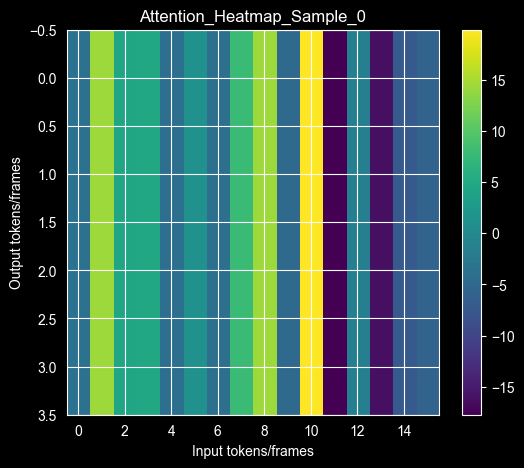

Saved: figures\Attention_Heatmap_Sample_0.png


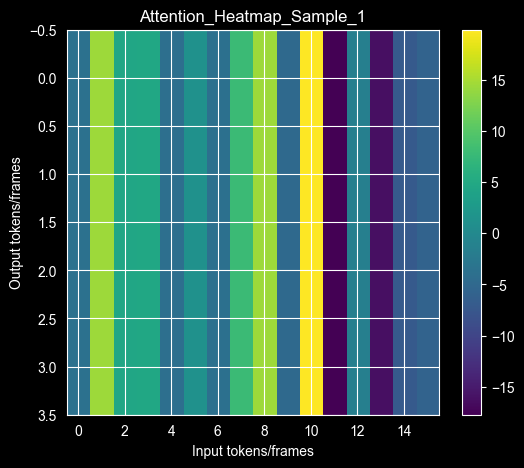

Saved: figures\Attention_Heatmap_Sample_1.png


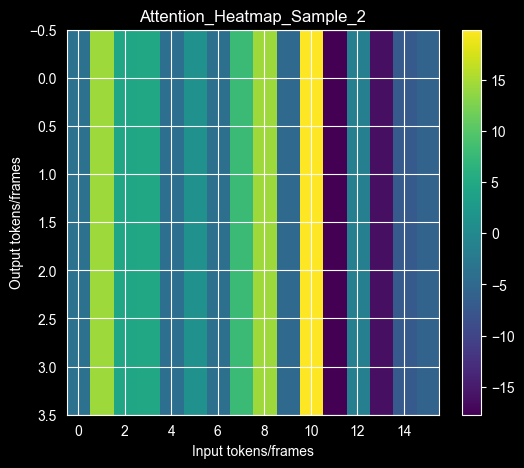

Saved: figures\Attention_Heatmap_Sample_2.png


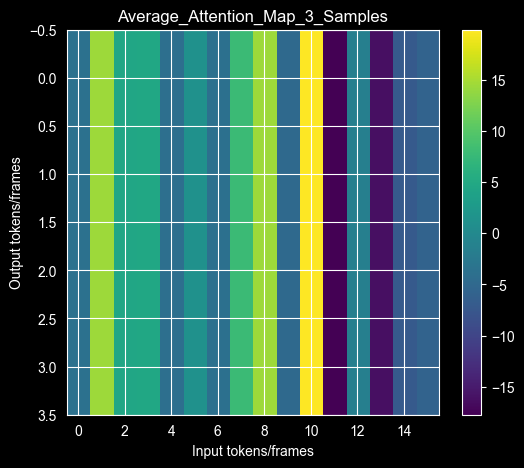

Saved: figures\Average_Attention_Map_3_Samples.png


In [38]:
# Plot attention / explainability maps for Figure 4
plot_attention_heatmaps(sequence_predictor, test_dataloader, device)

In [39]:
with open("Roberta_CNN_prediction_examples.json") as f:
    examples = json.load(f)

print(examples[0])

{'input_frames': [[[[0.29019609093666077, 0.29019609093666077, 0.29411765933036804, 0.2823529541492462, 0.2705882489681244, 0.2823529541492462, 0.2980392277240753, 0.3960784375667572, 0.8784313797950745, 0.9411764740943909, 0.95686274766922, 0.8078431487083435, 0.24705882370471954, 0.2078431397676468, 0.20392157137393951, 0.2078431397676468, 0.2235294133424759, 0.2235294133424759, 0.21176470816135406, 0.1921568661928177, 0.1568627506494522, 0.13333334028720856, 0.10588235408067703, 0.09019608050584793, 0.09019608050584793, 0.0784313753247261, 0.16862745583057404, 0.21960784494876862, 0.250980406999588, 0.30980393290519714, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.32549020648002625, 0.34117648005485535, 0.34117648005485535, 0.34117648005485535, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.364

In [40]:
def show_full_example(example):
    frames = np.array(example["input_frames"])
    gt_img = np.array(example["ground_truth_image"])
    pred_img = np.array(example["predicted_image"])

    fig, axes = plt.subplots(2, 4, figsize=(12,6))

    # Input frames
    for i in range(4):
        img = frames[i].transpose(1,2,0)
        axes[0,i].imshow(img)
        axes[0,i].axis('off')
        axes[0,i].set_title(f"Input {i+1}")

    # Ground truth image
    gt_img = gt_img.transpose(1,2,0)
    axes[1,1].imshow(gt_img)
    axes[1,1].set_title("Ground Truth Image")
    axes[1,1].axis('off')

    # Predicted image
    pred_img = pred_img.transpose(1,2,0)
    axes[1,2].imshow(pred_img)
    axes[1,2].set_title("Predicted Image")
    axes[1,2].axis('off')

    # Hide unused plots
    axes[1,0].axis('off')
    axes[1,3].axis('off')

    plt.tight_layout()
    plt.show()

    print("\n--- TEXT ---")
    print("Ground Truth:\n", example["ground_truth_text"])
    print("\nPrediction:\n", example["predicted_text"])


=== Example 1 ===


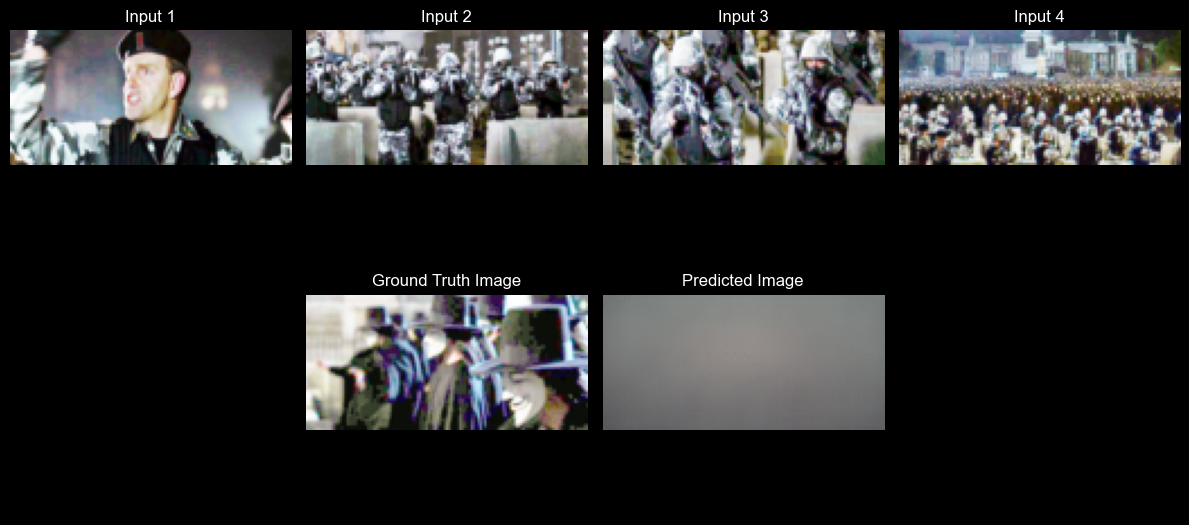


--- TEXT ---
Ground Truth:
 The night was thick with tension as Officer Smith stood in the heart of the Military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The Officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed to make a choice, one that could either save or condemn many

Prediction:
 In air was the with the. the was,, the weight of the weight was, The of, the the. weight of the weight sense, the sense, the to the weight of the, The was,. the weight, the,, the,, the, the mind,, sense of the, the, The of was, the.In, the,. the was The was the weight of the, the.. and of The to the the was. the,, the was the the, was to the the sense, the. the was,, and he,

=== Example 2 ==

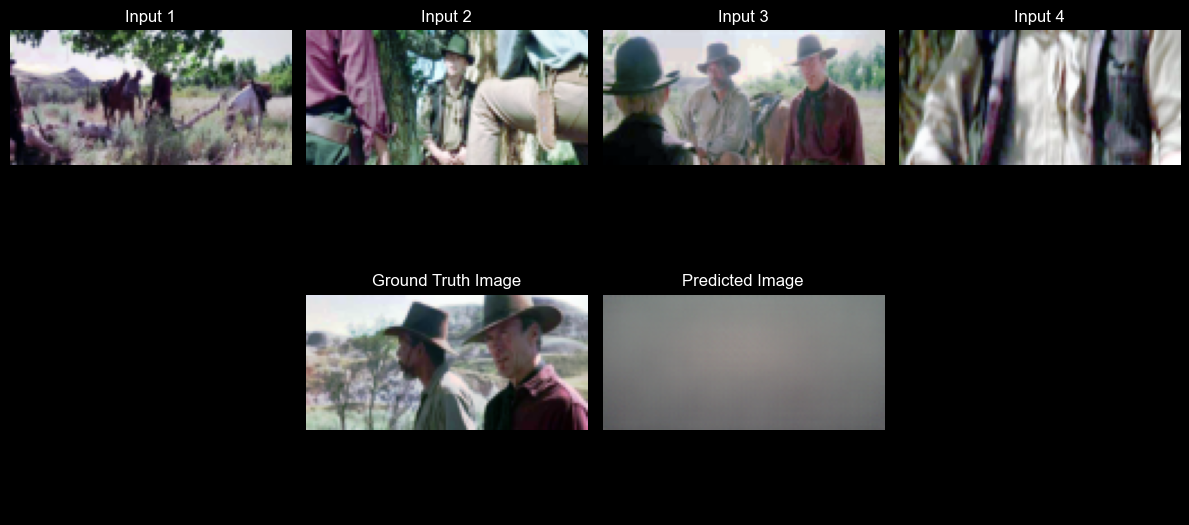


--- TEXT ---
Ground Truth:
 In the Open field with bushes and trees, John stood near the brown horse, feeling a sense of determination mixed with unease. He knew that today would be a crucial day. As he tended to the horse, he could see the white horse in the distance, a symbol of the journey ahead. The calm environment seemed to mock the tension building inside him. Little did he know, the events of this day would change everything.

Prediction:
 In the weight of, the, the, the,, the weight,. the. sense of the,. thease, The was, the, lit the sense to. The the was, the weight, the was was, weight,. the weight, the sense of the weight,, The of was, to the the weight,, the, The did the was, the weight, the was, to,. The was,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

=== Example 3 ===


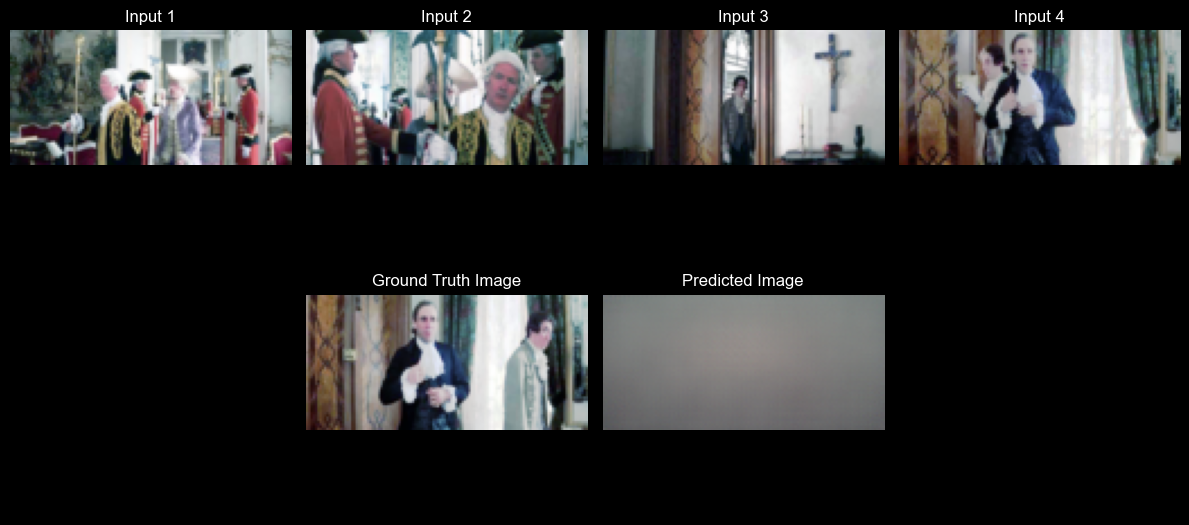


--- TEXT ---
Ground Truth:
 In the quiet, neutral-toned room adorned with the wall and the rug, Alice, Bob, and Carol stood in a tense silence. The air was thick with unspoken words and hidden agendas. Alice felt the weight of her past decisions pressing down on her shoulders. Bob, with his short brown hair, tried to maintain a composed demeanor, but his eyes betrayed his anxiety. Carol, with her curly blonde hair, stood slightly apart, her mind racing with thoughts of the confrontation that was about to unfold.

Prediction:
 In the weight of the,.,,,. the weight, the weight the the, the, the the., the sense of. The of, the with the the,. the,, The, the weight of the mind.,,, the mind. The, the the mind,, the the to the, sense the. the the mindase the mind, The, the the mind,, the the of,, the mind.. the. the weight, the a to the, The was,,,,,,,,,,,,,,


In [41]:
for idx, example in enumerate(examples[:3]): # the first 3
    print(f"\n=== Example {idx+1} ===")
    show_full_example(example)